### Eye Detection using OpenCV

To detect eyes, we'll first need to install OpenCV. Then, we'll use pre-trained Haar cascade classifiers provided by OpenCV for face and eye detection. The general workflow will be:

1.  **Load the necessary libraries and classifiers.**
2.  **Load an image.**
3.  **Convert the image to grayscale.**
4.  **Detect faces in the image.**
5.  **For each detected face, detect eyes within the face region.**
6.  **Draw rectangles around the detected eyes.**

In [1]:
# Install OpenCV if you haven't already
# !pip install opencv-python

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the pre-trained face and eye cascade classifiers
# You might need to download these XML files if they are not present
# You can find them in the OpenCV GitHub repository:
# https://github.com/opencv/opencv/tree/master/data/haarcascades
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

if face_cascade.empty():
    raise IOError('Unable to load the face cascade classifier xml file')
if eye_cascade.empty():
    raise IOError('Unable to load the eye cascade classifier xml file')

print("Cascade classifiers loaded successfully.")

Cascade classifiers loaded successfully.


Now, let's load an image and perform eye detection. For demonstration purposes, I will use a placeholder image. You can replace `image_path` with the path to your own image.

First, I'll create a dummy image programmatically for testing purposes.

Found 1 face(s)
Found 3 eye(s) in this face


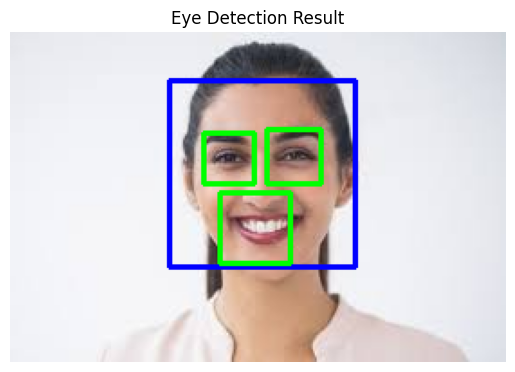

In [2]:
# Create a dummy image for demonstration purposes
# In a real scenario, you would load an image from a file:
# img = cv2.imread('path/to/your/image.jpg')

# For now, let's create a black image with a white rectangle to simulate a face
# This is just a placeholder; for actual eye detection, you need a real image.
image_path = '/content/human image.jpeg' # Updated to use the user's provided image

try:
    # Attempt to load the user's image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image from {image_path}. Please ensure the file exists and is correctly named.")
except Exception as e:
    print(f"Error loading image: {e}. Creating a dummy image instead.")
    # Create a dummy image if sample image loading fails
    img = np.zeros((400, 600, 3), dtype=np.uint8)
    cv2.rectangle(img, (150, 100), (450, 300), (255, 255, 255), -1) # White rectangle as 'face'
    cv2.putText(img, 'Could not load your image. Displaying dummy image.', (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)


if img is None:
    print("Error: Could not load or create image.")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    # The detectMultiScale function detects objects of different sizes in the input image.
    # The detected objects are returned as a list of rectangles.
    # 1.3 is the scale factor: how much the image size is reduced at each image scale.
    # 5 is the minNeighbors: how many neighbors each candidate rectangle should have to retain it.
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    print(f"Found {len(faces)} face(s)")

    # Draw rectangles around the faces and then detect eyes within each face
    for (x, y, w, h) in faces:
        # Draw rectangle around face
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue rectangle for face

        # Region of Interest for the face (in grayscale and color)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        # Detect eyes within the face region
        # The parameters here might need tuning based on image quality and eye size
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 3)

        print(f"Found {len(eyes)} eye(s) in this face")

        # Draw rectangles around the eyes
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green rectangle for eyes

    # Display the result
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Eye Detection Result')
    plt.axis('off')
    plt.show()